# Evaluación Parcial N°1 — Deep Learning
### Asignatura: DLY0100 · Deep Learning
### Profesor: Edwin Orlando Sanchez Valderrama
### Estudiante: Inti Escobar
---

## Introducción

### Descripción del Problema

Este proyecto aborda un problema de clasificación binaria en el ámbito de la salud cardiovascular. El objetivo es predecir si un paciente tiene o no enfermedad cardíaca, a partir de un conjunto de variables clínicas.

**Dataset:** Heart Disease UCI  
**Fuente:** UCI Machine Learning Repository  
**Variables:** 13 atributos clínicos + 1 variable objetivo (target)  
**Registros:** 303 pacientes  
**Variable objetivo:** `target` → 1 = presencia de enfermedad cardíaca / 0 = ausencia

### Objetivo del Modelo

Implementar una Red Neuronal Artificial Multicapa (MLP) utilizando TensorFlow/Keras para clasificar pacientes en riesgo cardíaco, siguiendo la metodología CRISP-DM.

---

### Metodología CRISP-DM

| Fase | Descripción |
|------|-------------|
| 1. Comprensión del negocio | Identificar el problema clínico y los objetivos |
| 2. Comprensión de los datos | Exploración y análisis estadístico del dataset |
| 3. Preparación de los datos | Limpieza, codificación y normalización |
| 4. Modelado | Diseño y entrenamiento del MLP con TensorFlow/Keras |
| 5. Evaluación | Métricas de desempeño y comparación de configuraciones |
| 6. Despliegue | Conclusiones y recomendaciones finales |

---

### Variables del Dataset

| Variable | Descripción | Tipo |
|----------|-------------|------|
| `age` | Edad del paciente (años) | Numérica |
| `sex` | Sexo (1=masculino, 0=femenino) | Categórica |
| `cp` | Tipo de dolor torácico (0–3) | Categórica |
| `trestbps` | Presión arterial en reposo (mm Hg) | Numérica |
| `chol` | Colesterol sérico (mg/dl) | Numérica |
| `fbs` | Glucemia en ayuno > 120 mg/dl (1=verdadero) | Categórica |
| `restecg` | Resultados ECG en reposo (0–2) | Categórica |
| `thalach` | Frecuencia cardíaca máxima alcanzada | Numérica |
| `exang` | Angina inducida por ejercicio (1=sí) | Categórica |
| `oldpeak` | Depresión del ST inducida por ejercicio | Numérica |
| `slope` | Pendiente del segmento ST máximo (0–2) | Categórica |
| `ca` | N° de vasos principales coloreados (0–3) | Numérica |
| `thal` | Talasemia (1=normal, 2=defecto fijo, 3=defecto reversible) | Categórica |
| `target` | Diagnóstico de enfermedad cardíaca (1=sí, 0=no) | **Objetivo** |

---
## Fase 0: Instalación e Importación de Librerías

In [21]:
# ─── Instalación de dependencias (solo necesario en Google Colab) ───
# !pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy

# ─── Librerías estándar ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── TensorFlow / Keras ───
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ─── Scikit-learn ───
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# ─── Reproducibilidad ───
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Configuración visual ───
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

print(f' TensorFlow versión: {tf.__version__}')
print(f' NumPy versión: {np.__version__}')
print(f' Pandas versión: {pd.__version__}')
print(' Todas las librerías importadas correctamente.')

 TensorFlow versión: 2.19.0
 NumPy versión: 2.0.2
 Pandas versión: 2.2.2
 Todas las librerías importadas correctamente.


---
## Fase 1: Comprensión y Carga de Datos (CRISP-DM)

En esta fase cargamos el dataset y realizamos una exploración inicial para comprender su estructura, tipos de variables y posibles problemas de calidad de datos.

**Decisiones tomadas:**
- Se carga directamente desde archivo CSV para garantizar reproducibilidad.
- Se verifica la existencia de valores nulos y duplicados antes de cualquier transformación.
- Se analiza la distribución de la variable objetivo para detectar posible desbalance de clases.

In [22]:
# ─── Carga del dataset ───
# En Google Colab puede cargarse desde Google Drive o directamente:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('heart.csv')  # Ajustar ruta según sea necesario

print('=' * 55)
print('         INFORMACIÓN GENERAL DEL DATASET')
print('=' * 55)
print(f'  Filas (pacientes):   {df.shape[0]}')
print(f'  Columnas (variables): {df.shape[1]}')
print(f'  Valores nulos:       {df.isnull().sum().sum()}')
print(f'  Registros duplicados: {df.duplicated().sum()}')
print('=' * 55)
print()
print('Primeras 5 filas:')
display(df.head())

         INFORMACIÓN GENERAL DEL DATASET
  Filas (pacientes):   303
  Columnas (variables): 14
  Valores nulos:       0
  Registros duplicados: 1

Primeras 5 filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [23]:
# ─── Estadísticas descriptivas ───
print('Estadísticas descriptivas del dataset:')
display(df.describe().round(2))

Estadísticas descriptivas del dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [24]:
# ─── Tipos de datos por columna ───
print('Tipos de datos:')
print(df.dtypes.to_string())
print()

# ─── Distribución de la variable objetivo ───
conteo = df['target'].value_counts()
print('\nDistribución de la variable objetivo (target):')
print(f'  Clase 1 (con enfermedad): {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)')
print(f'  Clase 0 (sin enfermedad): {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)')
print(f'  Ratio de desbalance: {conteo[1]/conteo[0]:.2f}:1  → Dataset razonablemente balanceado')

Tipos de datos:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64


Distribución de la variable objetivo (target):
  Clase 1 (con enfermedad): 165 (54.5%)
  Clase 0 (sin enfermedad): 138 (45.5%)
  Ratio de desbalance: 1.20:1  → Dataset razonablemente balanceado


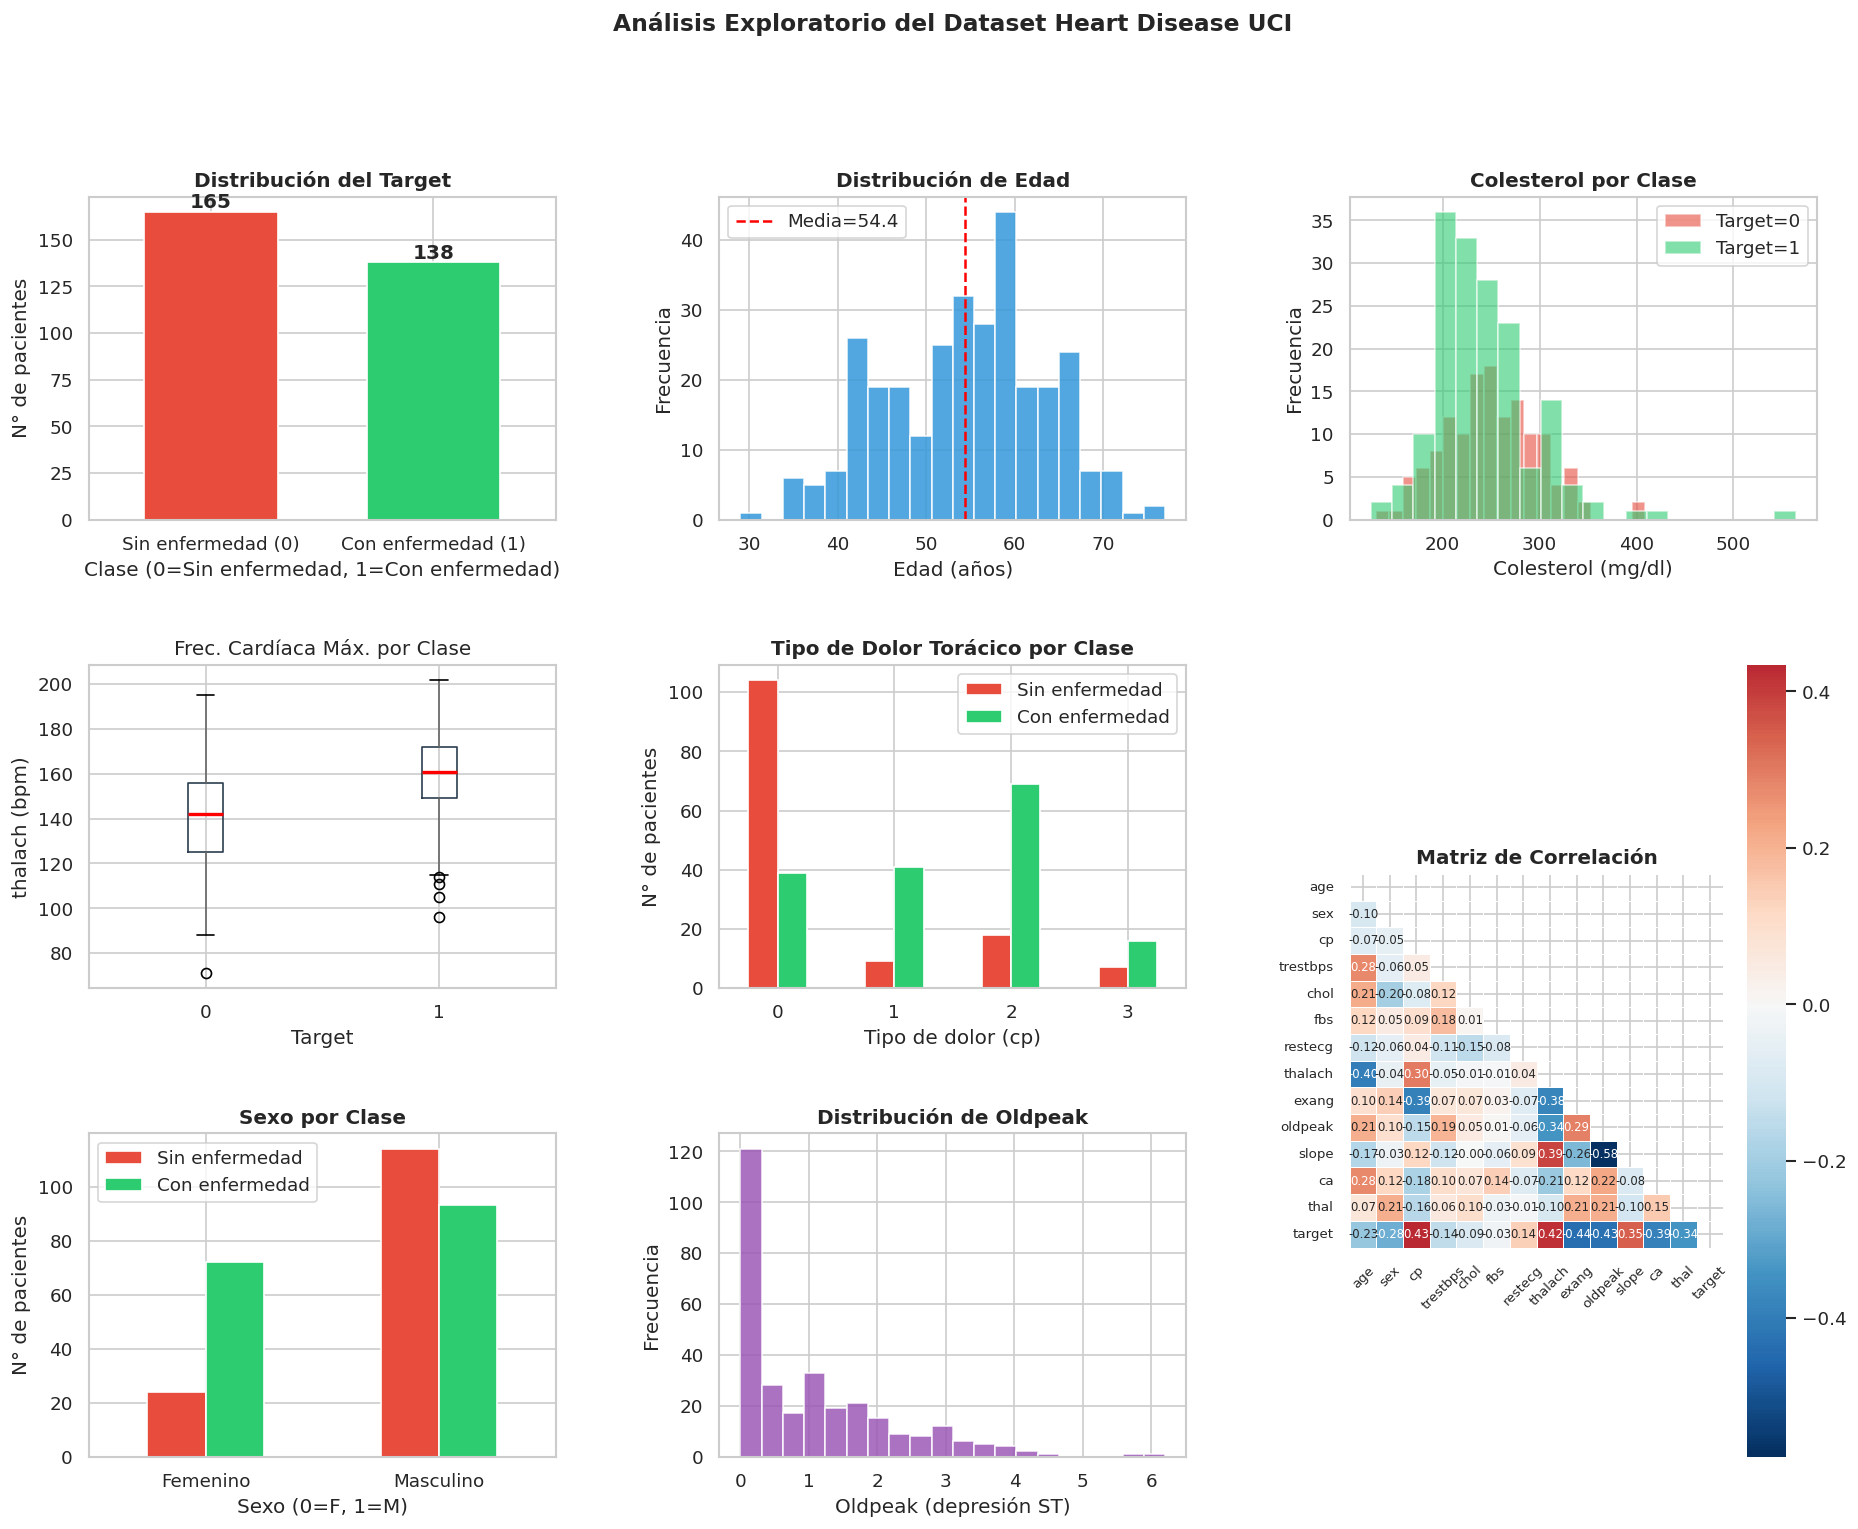

 Visualización exploratoria completada.


In [25]:
# ─── Visualización exploratoria ───
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Distribución del target
ax0 = fig.add_subplot(gs[0, 0])
colores = ['#E74C3C', '#2ECC71']
df['target'].value_counts().plot(kind='bar', ax=ax0, color=colores, edgecolor='white', width=0.6)
ax0.set_title('Distribución del Target', fontweight='bold')
ax0.set_xlabel('Clase (0=Sin enfermedad, 1=Con enfermedad)')
ax0.set_ylabel('N° de pacientes')
ax0.set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'], rotation=0)
for p in ax0.patches:
    ax0.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

# 2. Distribución de edad
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(df['age'], bins=20, color='#3498DB', edgecolor='white', alpha=0.85)
ax1.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Media={df["age"].mean():.1f}')
ax1.set_title('Distribución de Edad', fontweight='bold')
ax1.set_xlabel('Edad (años)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# 3. Colesterol por clase
ax2 = fig.add_subplot(gs[0, 2])
for clase, color in zip([0, 1], ['#E74C3C', '#2ECC71']):
    ax2.hist(df[df['target'] == clase]['chol'], bins=20, alpha=0.6,
             color=color, label=f'Target={clase}', edgecolor='white')
ax2.set_title('Colesterol por Clase', fontweight='bold')
ax2.set_xlabel('Colesterol (mg/dl)')
ax2.set_ylabel('Frecuencia')
ax2.legend()

# 4. Frecuencia cardíaca máxima por clase
ax3 = fig.add_subplot(gs[1, 0])
df.boxplot(column='thalach', by='target', ax=ax3,
           boxprops=dict(color='#2C3E50'), medianprops=dict(color='red', linewidth=2))
ax3.set_title('Frec. Cardíaca Máx. por Clase', fontweight='bold')
ax3.set_xlabel('Target')
ax3.set_ylabel('thalach (bpm)')
plt.sca(ax3)
plt.title('Frec. Cardíaca Máx. por Clase')

# 5. Tipo de dolor torácico por clase
ax4 = fig.add_subplot(gs[1, 1])
pd.crosstab(df['cp'], df['target']).plot(kind='bar', ax=ax4,
    color=['#E74C3C', '#2ECC71'], edgecolor='white')
ax4.set_title('Tipo de Dolor Torácico por Clase', fontweight='bold')
ax4.set_xlabel('Tipo de dolor (cp)')
ax4.set_ylabel('N° de pacientes')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(['Sin enfermedad', 'Con enfermedad'])

# 6. Mapa de calor de correlaciones
ax5 = fig.add_subplot(gs[1:, 2])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax5, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, square=True)
ax5.set_title('Matriz de Correlación', fontweight='bold')
ax5.tick_params(axis='x', rotation=45, labelsize=8)
ax5.tick_params(axis='y', rotation=0, labelsize=8)

# 7. Sexo por clase
ax6 = fig.add_subplot(gs[2, 0])
pd.crosstab(df['sex'], df['target']).plot(kind='bar', ax=ax6,
    color=['#E74C3C', '#2ECC71'], edgecolor='white')
ax6.set_title('Sexo por Clase', fontweight='bold')
ax6.set_xlabel('Sexo (0=F, 1=M)')
ax6.set_ylabel('N° de pacientes')
ax6.set_xticklabels(['Femenino', 'Masculino'], rotation=0)
ax6.legend(['Sin enfermedad', 'Con enfermedad'])

# 8. Oldpeak distribución
ax7 = fig.add_subplot(gs[2, 1])
ax7.hist(df['oldpeak'], bins=20, color='#9B59B6', edgecolor='white', alpha=0.85)
ax7.set_title('Distribución de Oldpeak', fontweight='bold')
ax7.set_xlabel('Oldpeak (depresión ST)')
ax7.set_ylabel('Frecuencia')

fig.suptitle('Análisis Exploratorio del Dataset Heart Disease UCI',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eda_exploratorio.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Visualización exploratoria completada.')

---
## Fase 2: Preparación y Preprocesamiento de Datos (CRISP-DM)

El preprocesamiento es una etapa crítica para garantizar la calidad del entrenamiento. Se aplican las siguientes transformaciones:

| Paso | Técnica | Justificación |
|------|---------|---------------|
| 1 | Eliminación de duplicados | Evitar que el modelo memorice registros repetidos |
| 2 | Separación X/y | Dividir features y variable objetivo |
| 3 | Train/Validation/Test split | Evaluar generalización real (70/15/15) |
| 4 | **StandardScaler** | Las redes neuronales son sensibles a la escala; normalizar acelera convergencia |

**Decisión clave — Normalización:** Se usa `StandardScaler` (media=0, std=1) en lugar de MinMax porque el dataset tiene outliers potenciales en variables como `chol` y `trestbps`. StandardScaler es más robusto ante estos casos.

In [26]:
# ─── 1. Eliminar duplicados ───
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicados eliminados: {n_antes - len(df)} | Registros restantes: {len(df)}')

# ─── 2. Separar features y target ───
X = df.drop('target', axis=1)
y = df['target']

# ─── 3. División estratificada train / val / test (70 / 15 / 15) ───
# Estratificada: garantiza la misma proporción de clases en cada split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp
    # 0.176 ≈ 15/85 para obtener 15% del total en validación
)

print(f'\nDivisión del dataset (estratificada):')
print(f'  Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(df)*100:.0f}%)')
print(f'  Validación:    {len(X_val)} muestras ({len(X_val)/len(df)*100:.0f}%)')
print(f'  Prueba:        {len(X_test)} muestras ({len(X_test)/len(df)*100:.0f}%)')

# ─── 4. Normalización con StandardScaler ───
# IMPORTANTE: el scaler se ajusta SOLO con los datos de entrenamiento
# para evitar data leakage hacia validación/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # solo transform
X_test_scaled  = scaler.transform(X_test)         # solo transform

print(f'\nNormalización aplicada (StandardScaler):')
print(f'  Media del conjunto de entrenamiento (post-scale): {X_train_scaled.mean():.6f}')
print(f'  Std del conjunto de entrenamiento (post-scale):   {X_train_scaled.std():.6f}')
print('\n Preprocesamiento completado.')

Duplicados eliminados: 1 | Registros restantes: 302

División del dataset (estratificada):
  Entrenamiento: 210 muestras (70%)
  Validación:    46 muestras (15%)
  Prueba:        46 muestras (15%)

Normalización aplicada (StandardScaler):
  Media del conjunto de entrenamiento (post-scale): 0.000000
  Std del conjunto de entrenamiento (post-scale):   1.000000

 Preprocesamiento completado.


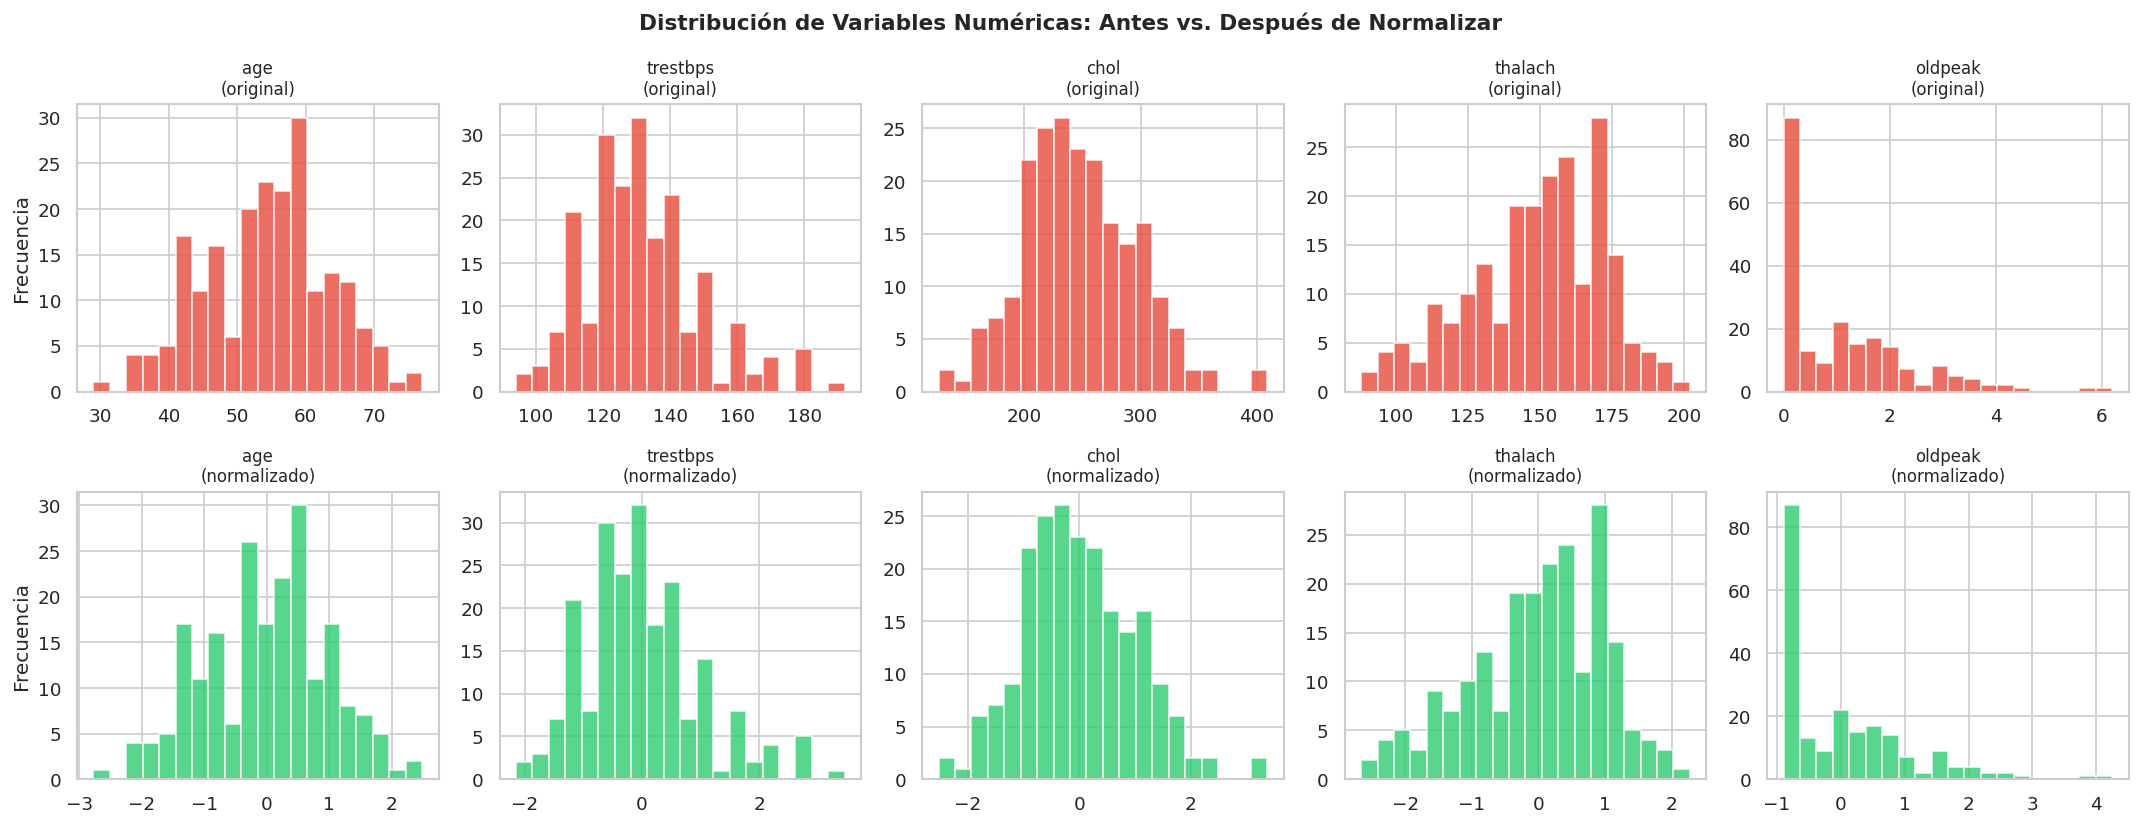

 La normalización centra las distribuciones en torno a μ=0, σ=1.


In [27]:
# ─── Verificación visual: distribución antes y después de normalizar ───
variables_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
indices = [X.columns.get_loc(c) for c in variables_numericas]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Distribución de Variables Numéricas: Antes vs. Después de Normalizar',
             fontweight='bold', fontsize=13)

for i, (col, idx) in enumerate(zip(variables_numericas, indices)):
    # Antes
    axes[0, i].hist(X_train[col], bins=20, color='#E74C3C', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col}\n(original)', fontsize=10)
    if i == 0: axes[0, i].set_ylabel('Frecuencia')

    # Después
    axes[1, i].hist(X_train_scaled[:, idx], bins=20, color='#2ECC71', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{col}\n(normalizado)', fontsize=10)
    if i == 0: axes[1, i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('normalizacion.png', bbox_inches='tight', dpi=150)
plt.show()
print(' La normalización centra las distribuciones en torno a μ=0, σ=1.')

---
## Fase 3: Funciones de Activación — Teoría y Comparación

### 3.1 Definición de Funciones de Activación

Las funciones de activación son el componente no-lineal de la red neuronal que permite aprender representaciones complejas. Sin ellas, el MLP sería equivalente a una regresión lineal.

| Función | Fórmula | Rango | Uso recomendado |
|---------|---------|-------|----------------|
| **ReLU** | max(0, x) | [0, ∞) | Capas ocultas (estándar) |
| **Sigmoid** | 1/(1+e⁻ˣ) | (0, 1) | Capa de salida binaria |
| **Tanh** | (eˣ−e⁻ˣ)/(eˣ+e⁻ˣ) | (−1, 1) | Capas ocultas (alternativa) |
| **ELU** | x si x>0, α(eˣ−1) si x≤0 | (−α, ∞) | Capas ocultas (robusto) |

**Función de error (pérdida):** Para clasificación binaria se utiliza **Binary Cross-Entropy**:
$$L = -\frac{1}{N}\sum_{i=1}^{N}[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$

**Función de salida:** **Sigmoid** → produce una probabilidad p ∈ (0,1) que representa la probabilidad de pertenecer a la clase 1.

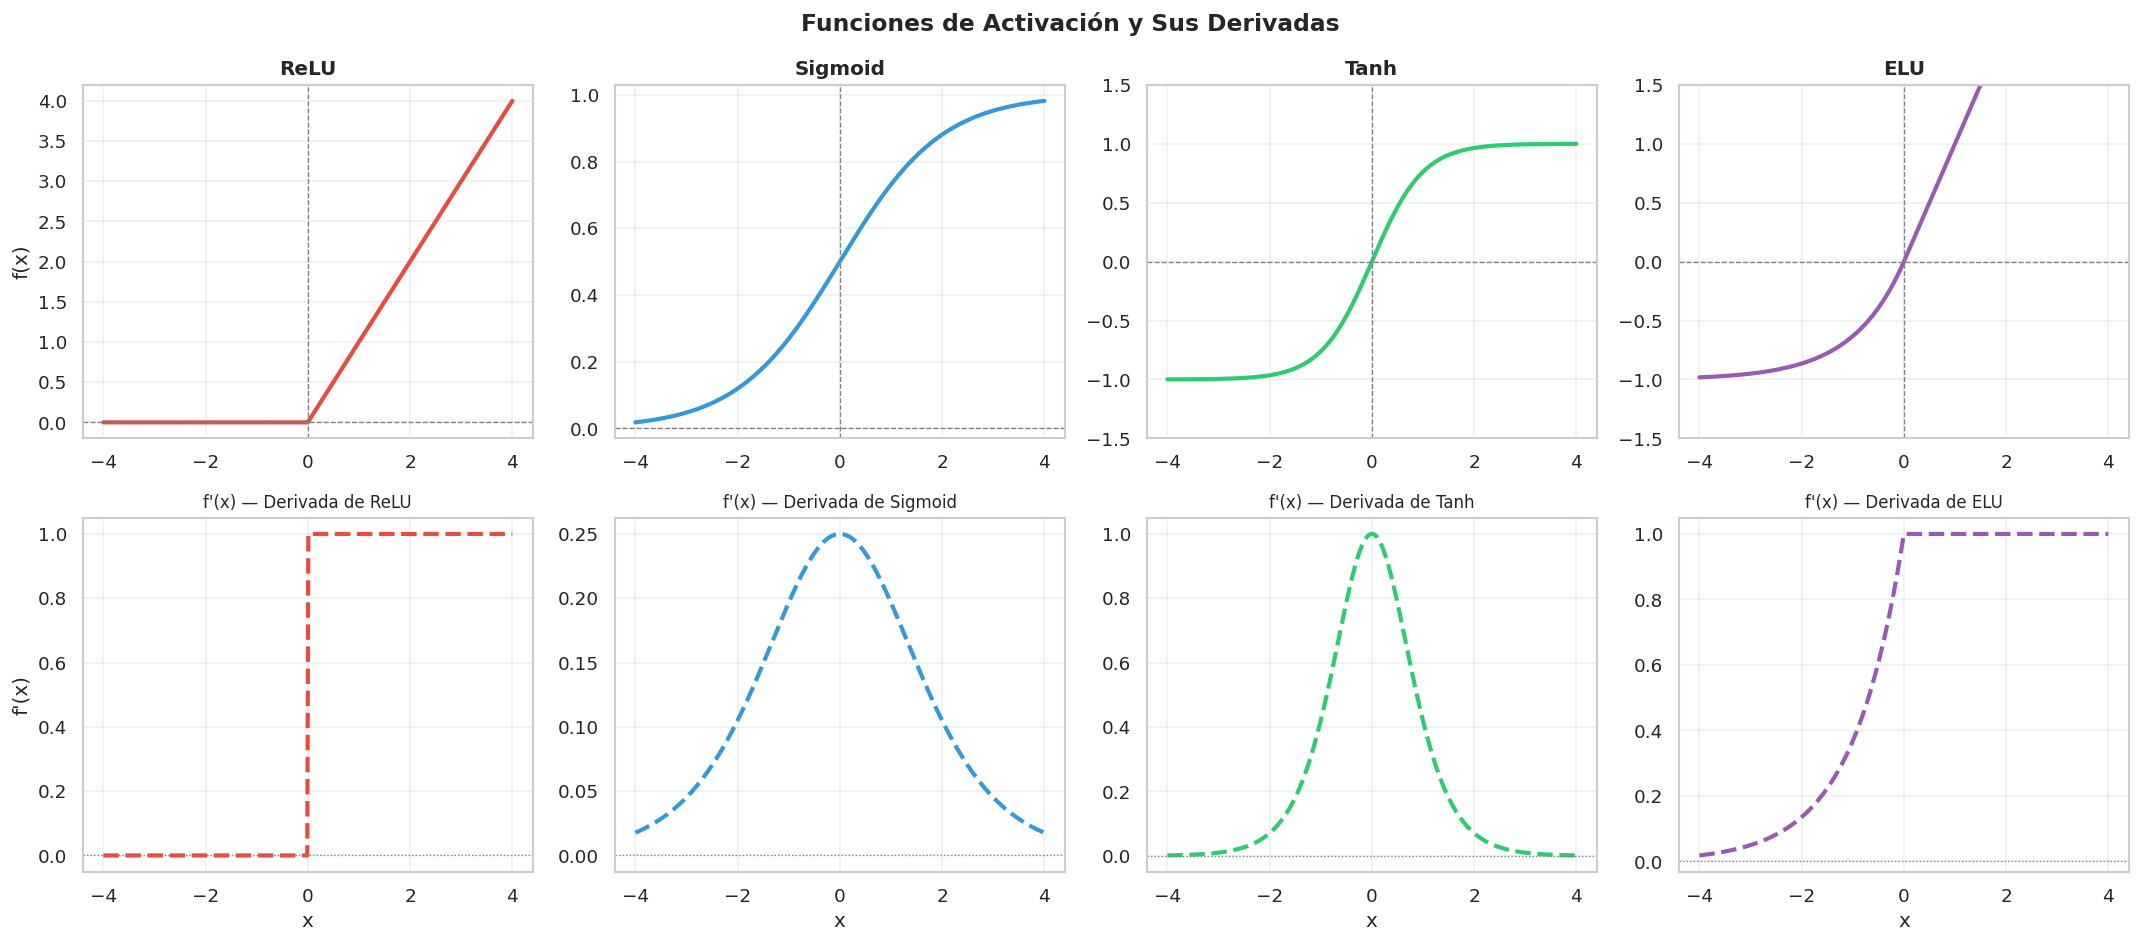

 Las derivadas determinan el gradiente durante la retropropagación.
   ReLU evita el "Vanishing Gradient" mejor que Sigmoid y Tanh.


In [28]:
# ─── Visualización de funciones de activación y sus derivadas ───
x = np.linspace(-4, 4, 400)

# Calcular funciones
relu   = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh_f = np.tanh(x)
alpha = 1.0
elu    = np.where(x > 0, x, alpha * (np.exp(x) - 1))

# Derivadas
d_relu    = np.where(x > 0, 1.0, 0.0)
d_sigmoid = sigmoid * (1 - sigmoid)
d_tanh    = 1 - tanh_f**2
d_elu     = np.where(x > 0, 1.0, alpha * np.exp(x))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Funciones de Activación y Sus Derivadas', fontweight='bold', fontsize=14)

config = [
    ('ReLU', relu, d_relu, '#E74C3C'),
    ('Sigmoid', sigmoid, d_sigmoid, '#3498DB'),
    ('Tanh', tanh_f, d_tanh, '#2ECC71'),
    ('ELU', elu, d_elu, '#9B59B6'),
]

for i, (nombre, f, df_, color) in enumerate(config):
    # Función
    axes[0, i].plot(x, f, color=color, linewidth=2.5)
    axes[0, i].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[0, i].axvline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[0, i].set_title(f'{nombre}', fontweight='bold')
    axes[0, i].set_ylabel('f(x)' if i == 0 else '')
    axes[0, i].set_ylim(-1.5, 1.5) if nombre in ['Tanh', 'ELU'] else None
    axes[0, i].grid(True, alpha=0.3)

    # Derivada
    axes[1, i].plot(x, df_, color=color, linewidth=2.5, linestyle='--')
    axes[1, i].axhline(0, color='gray', linewidth=0.8, linestyle=':')
    axes[1, i].set_title(f"f'(x) — Derivada de {nombre}", fontsize=10)
    axes[1, i].set_ylabel("f'(x)" if i == 0 else '')
    axes[1, i].set_xlabel('x')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('funciones_activacion.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Las derivadas determinan el gradiente durante la retropropagación.')
print('   ReLU evita el "Vanishing Gradient" mejor que Sigmoid y Tanh.')

---
## Fase 4: Modelado — Implementación del MLP (CRISP-DM)

### 4.1 Arquitectura del MLP

Se diseña un **Perceptrón Multicapa (MLP)** con la siguiente arquitectura base:

```
Input Layer  → 13 neuronas (una por feature)
Hidden Layer 1 → 64 neuronas + BatchNorm + Dropout(0.3)
Hidden Layer 2 → 32 neuronas + BatchNorm + Dropout(0.2)
Hidden Layer 3 → 16 neuronas
Output Layer → 1 neurona + Sigmoid
```

**Justificación de la arquitectura:**
- **3 capas ocultas:** Captura relaciones no lineales complejas sin sobreajuste en este dataset pequeño.
- **Neuronas decrecientes (64→32→16):** Patrón tipo embudo que comprime la representación progresivamente.
- **BatchNormalization:** Estabiliza el entrenamiento y permite tasas de aprendizaje más altas.
- **Dropout:** Regularización que reduce el overfitting al desactivar neuronas aleatoriamente.

In [29]:
def construir_modelo(activation='relu', learning_rate=0.001,
                     dropout_1=0.3, dropout_2=0.2,
                     l2_reg=0.01, usar_batchnorm=True):
    """
    Construye un MLP configurable para clasificación binaria.

    Parámetros:
    -----------
    activation    : función de activación para capas ocultas
    learning_rate : tasa de aprendizaje para Adam
    dropout_1/2   : tasa de dropout por capa
    l2_reg        : coeficiente de regularización L2
    usar_batchnorm: si aplica BatchNormalization

    Retorna:
    --------
    modelo compilado de Keras
    """
    model = keras.Sequential(name='MLP_HeartDisease')

    # ── Capa de entrada ──
    model.add(layers.Input(shape=(13,)))

    # ── Capa oculta 1: 64 neuronas ──
    model.add(layers.Dense(64,
                           activation=activation,
                           kernel_regularizer=regularizers.l2(l2_reg),
                           name='hidden_1'))
    if usar_batchnorm:
        model.add(layers.BatchNormalization(name='batchnorm_1'))
    model.add(layers.Dropout(dropout_1, name='dropout_1'))

    # ── Capa oculta 2: 32 neuronas ──
    model.add(layers.Dense(32,
                           activation=activation,
                           kernel_regularizer=regularizers.l2(l2_reg),
                           name='hidden_2'))
    if usar_batchnorm:
        model.add(layers.BatchNormalization(name='batchnorm_2'))
    model.add(layers.Dropout(dropout_2, name='dropout_2'))

    # ── Capa oculta 3: 16 neuronas ──
    model.add(layers.Dense(16,
                           activation=activation,
                           name='hidden_3'))

    # ── Capa de salida: Sigmoid para clasificación binaria ──
    model.add(layers.Dense(1, activation='sigmoid', name='output'))

    # ── Compilación ──
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    return model

# ─── Instanciar y resumir el modelo base ───
modelo_base = construir_modelo()
modelo_base.summary()

# Contar parámetros
total_params = modelo_base.count_params()
print(f'\n Total de parámetros entrenables: {total_params:,}')

Model: "MLP_HeartDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)


 Total de parámetros entrenables: 3,905


---
## Fase 5: Entrenamiento y Análisis de Hiperparámetros

Se realizan **experimentos controlados** variando un hiperparámetro a la vez para entender su impacto en el entrenamiento. Los hiperparámetros clave son:

- **Épocas:** N° de veces que el modelo ve el dataset completo
- **Tasa de aprendizaje (lr):** Controla el tamaño del paso en el descenso por gradiente
- **Batch size:** N° de muestras por actualización de pesos
- **Función de activación:** Introduce no-linealidad en las capas ocultas

**Callbacks utilizados:**
- `EarlyStopping`: Detiene el entrenamiento si la val_loss no mejora en `patience` épocas → evita overfitting
- `ReduceLROnPlateau`: Reduce la lr automáticamente cuando la pérdida se estanca

In [30]:
# ─── Callbacks comunes ───
def get_callbacks(patience=15, min_lr=1e-6):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=min_lr,
            verbose=0
        )
    ]

def plot_historial(historiales, nombres, titulo, figsize=(14, 5)):
    """Grafica la pérdida y accuracy de uno o más entrenamientos."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    colores = plt.cm.Set1(np.linspace(0, 0.9, len(historiales)))

    for hist, nombre, color in zip(historiales, nombres, colores):
        epochs = range(1, len(hist.history['loss']) + 1)
        ax1.plot(epochs, hist.history['loss'],     color=color, label=f'{nombre} train')
        ax1.plot(epochs, hist.history['val_loss'], color=color, linestyle='--', label=f'{nombre} val', alpha=0.7)
        ax2.plot(epochs, hist.history['accuracy'],     color=color, label=f'{nombre} train')
        ax2.plot(epochs, hist.history['val_accuracy'], color=color, linestyle='--', label=f'{nombre} val', alpha=0.7)

    ax1.set_title('Binary Cross-Entropy Loss', fontweight='bold')
    ax1.set_xlabel('Épocas'); ax1.set_ylabel('Loss')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2.set_title('Accuracy (Exactitud)', fontweight='bold')
    ax2.set_xlabel('Épocas'); ax2.set_ylabel('Accuracy')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(titulo, fontweight='bold', fontsize=12)
    plt.tight_layout()
    return fig

print(' Funciones de entrenamiento y visualización definidas.')

 Funciones de entrenamiento y visualización definidas.


### 5.1 Experimento 1: Variación de la Tasa de Aprendizaje (Learning Rate)

Se varía la tasa de aprendizaje manteniendo todos los demás parámetros constantes.
- **Hipótesis:** Una lr muy alta causará oscilaciones; una muy baja convergirá lentamente.

  lr=0.0100 → Val Accuracy máx: 0.8696 | Épocas: 31
  lr=0.0010 → Val Accuracy máx: 0.8478 | Épocas: 83
  lr=0.0001 → Val Accuracy máx: 0.4565 | Épocas: 19


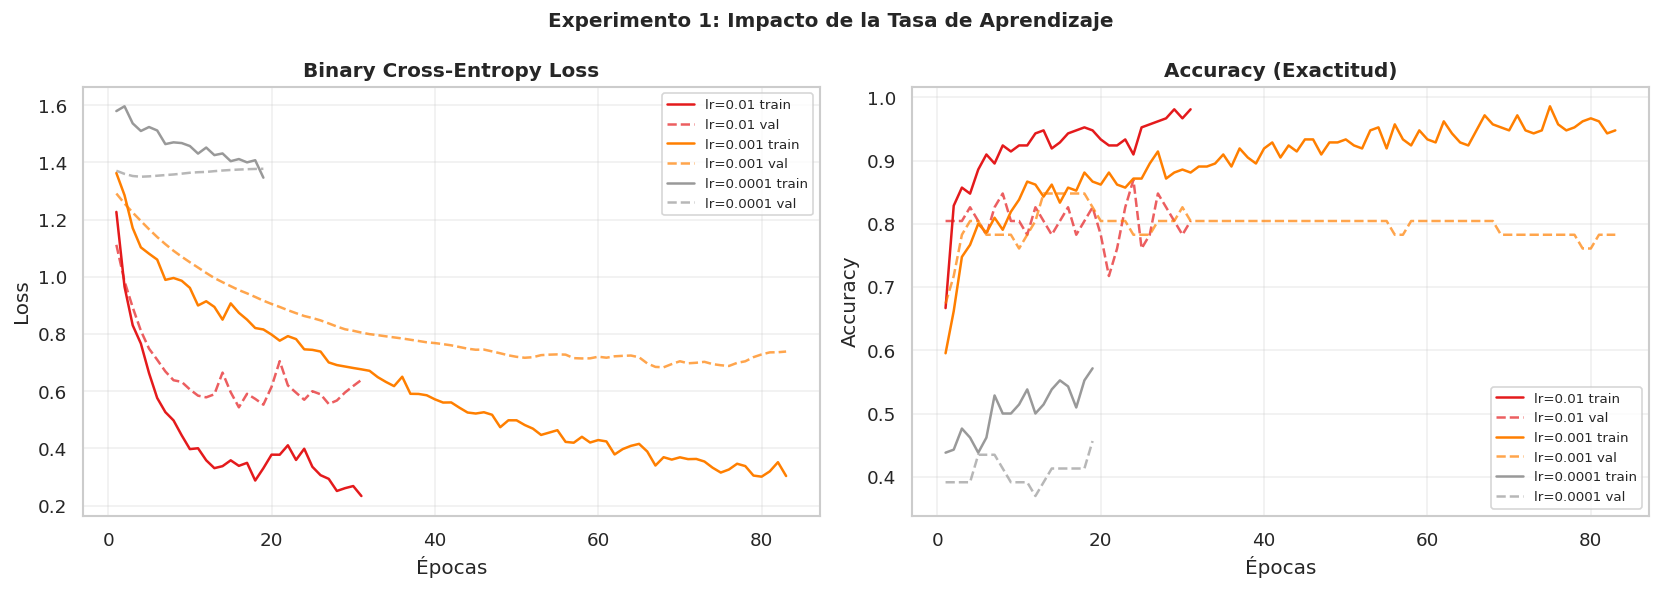


 Análisis:
  lr=0.01  → Converge rápido pero puede oscilar y overfittear
  lr=0.001 → Balance óptimo entre velocidad y estabilidad (seleccionada)
  lr=0.0001→ Convergencia muy lenta, necesita más épocas


In [31]:
# ─── Experimento 1: Learning Rate ───
learning_rates = [0.01, 0.001, 0.0001]
hist_lr = []

for lr in learning_rates:
    tf.random.set_seed(SEED)
    m = construir_modelo(learning_rate=lr)
    h = m.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=150, batch_size=32,
        callbacks=get_callbacks(),
        verbose=0
    )
    hist_lr.append(h)
    final_val_acc = max(h.history['val_accuracy'])
    print(f'  lr={lr:.4f} → Val Accuracy máx: {final_val_acc:.4f} | Épocas: {len(h.history["loss"])}')

fig = plot_historial(hist_lr, [f'lr={lr}' for lr in learning_rates],
                     'Experimento 1: Impacto de la Tasa de Aprendizaje')
plt.savefig('exp1_learning_rate.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n Análisis:')
print('  lr=0.01  → Converge rápido pero puede oscilar y overfittear')
print('  lr=0.001 → Balance óptimo entre velocidad y estabilidad (seleccionada)')
print('  lr=0.0001→ Convergencia muy lenta, necesita más épocas')

### 5.2 Experimento 2: Variación del Batch Size

El batch size afecta la varianza del gradiente y la velocidad de entrenamiento.
- **Batch pequeño (16):** Gradiente ruidoso → más regularización implícita, convergencia inestable.
- **Batch mediano (32):** Balance entre velocidad y estabilidad.
- **Batch grande (64):** Gradiente suave pero puede caer en mínimos locales.

  batch=16 → Val Accuracy máx: 0.8478 | Épocas: 56
  batch=32 → Val Accuracy máx: 0.8913 | Épocas: 96
  batch=64 → Val Accuracy máx: 0.8261 | Épocas: 96


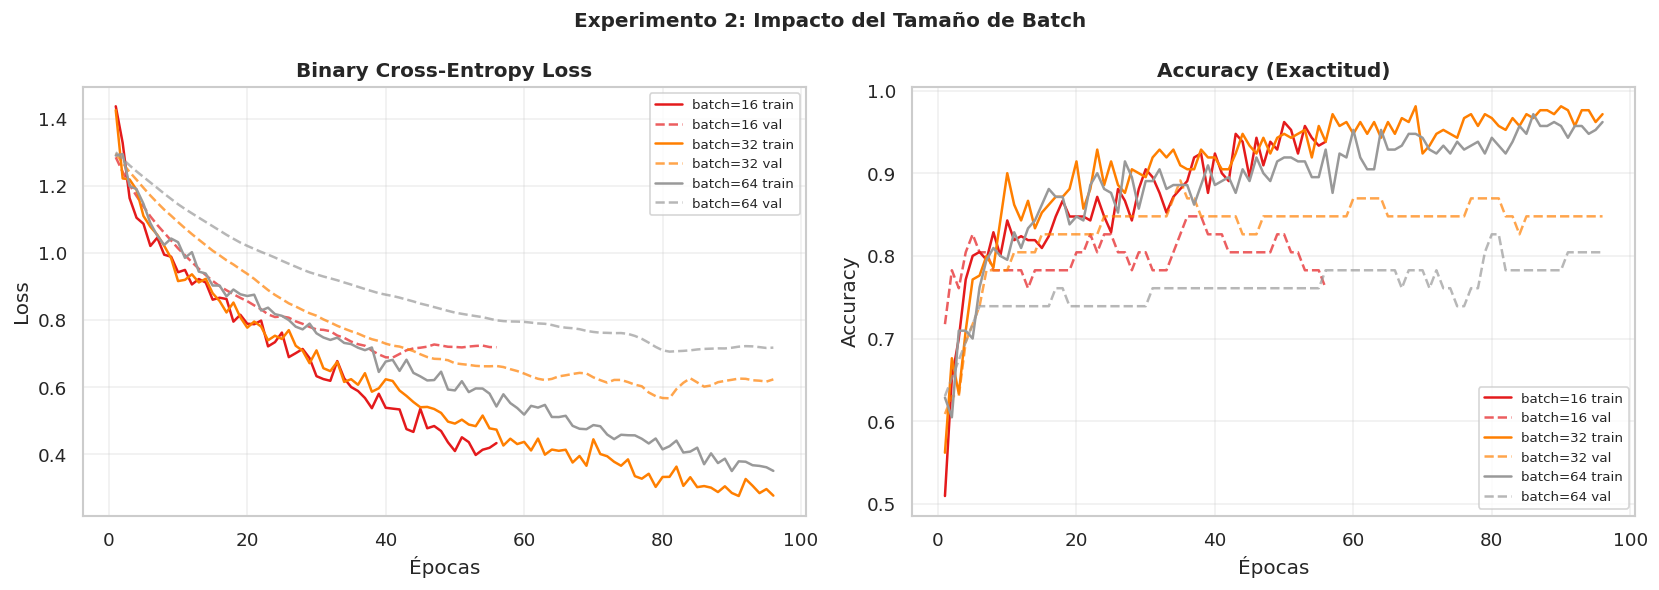

In [32]:
# ─── Experimento 2: Batch Size ───
batch_sizes = [16, 32, 64]
hist_batch = []

for bs in batch_sizes:
    tf.random.set_seed(SEED)
    m = construir_modelo(learning_rate=0.001)
    h = m.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=150, batch_size=bs,
        callbacks=get_callbacks(),
        verbose=0
    )
    hist_batch.append(h)
    final_val_acc = max(h.history['val_accuracy'])
    print(f'  batch={bs} → Val Accuracy máx: {final_val_acc:.4f} | Épocas: {len(h.history["loss"])}')

fig = plot_historial(hist_batch, [f'batch={bs}' for bs in batch_sizes],
                     'Experimento 2: Impacto del Tamaño de Batch')
plt.savefig('exp2_batch_size.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Experimento 3: Comparación de Funciones de Activación

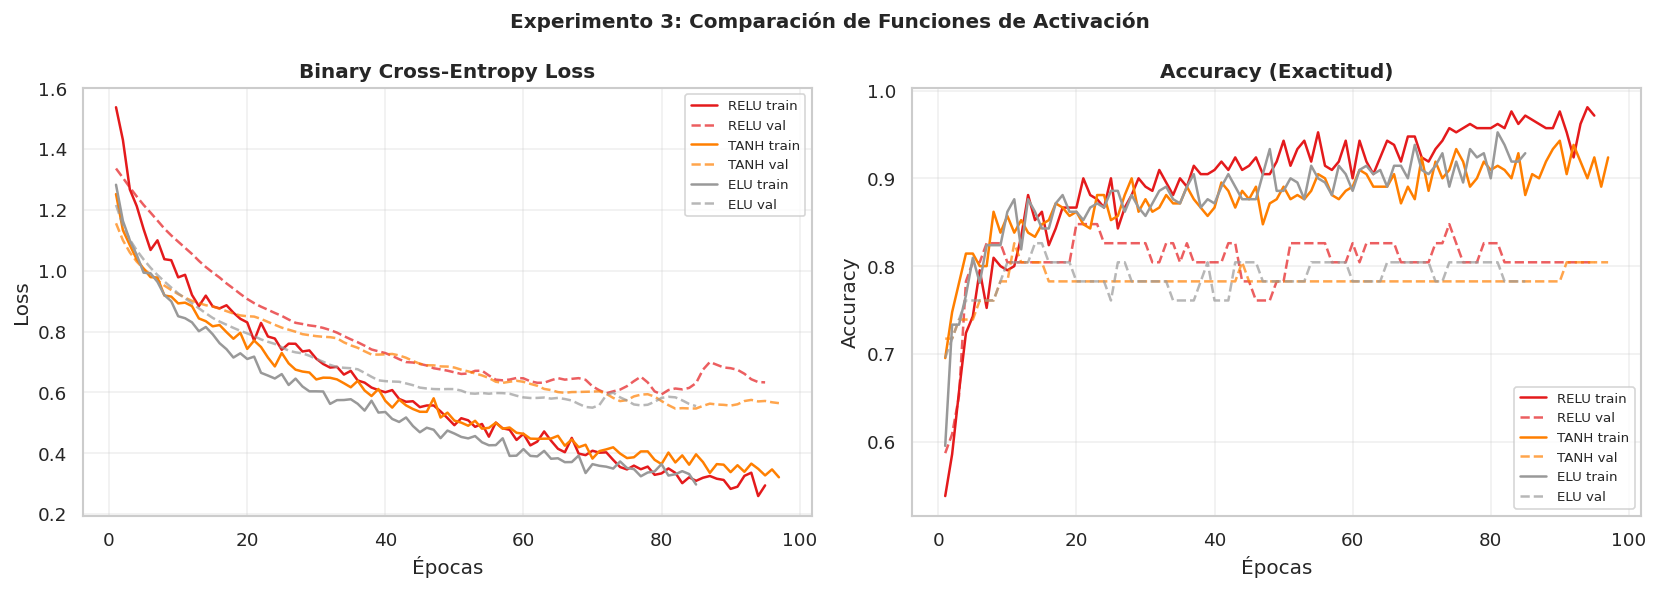


 Tabla Comparativa — Funciones de Activación (conjunto de validación):


,Accuracy,Precision,Recall,F1-Score,Épocas
Activación,,,,,
RELU,0.826100,0.793100,0.920000,0.851900,95
TANH,0.782600,0.741900,0.920000,0.821400,97
ELU,0.804300,0.766700,0.920000,0.836400,85


In [33]:
# ─── Experimento 3: Funciones de activación ───
activaciones = ['relu', 'tanh', 'elu']
hist_act = []
metricas_act = []

for act in activaciones:
    tf.random.set_seed(SEED)
    m = construir_modelo(activation=act, learning_rate=0.001)
    h = m.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=150, batch_size=32,
        callbacks=get_callbacks(),
        verbose=0
    )
    hist_act.append(h)

    # Evaluar en validación
    y_pred = (m.predict(X_val_scaled, verbose=0) >= 0.5).astype(int).flatten()
    metricas_act.append({
        'Activación': act.upper(),
        'Accuracy':  round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall':    round(recall_score(y_val, y_pred), 4),
        'F1-Score':  round(f1_score(y_val, y_pred), 4),
        'Épocas':    len(h.history['loss'])
    })

fig = plot_historial(hist_act, [a.upper() for a in activaciones],
                     'Experimento 3: Comparación de Funciones de Activación')
plt.savefig('exp3_activaciones.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabla comparativa
df_act = pd.DataFrame(metricas_act)
print('\n Tabla Comparativa — Funciones de Activación (conjunto de validación):')
display(df_act.set_index('Activación').style.highlight_max(axis=0, color='#d5f4e6'))

---
## Fase 6: Optimización del Modelo

### 6.1 Técnicas de Regularización y Optimización

Se comparan tres configuraciones:

| Config | Técnicas aplicadas |
|--------|--------------------|
| **Sin regularización** | Solo capas densas + ReLU + Sigmoid |
| **Con Dropout** | Dropout(0.3) y Dropout(0.2) en capas ocultas |
| **Completo** | Dropout + BatchNormalization + L2 Regularization |

**Justificación:**
- **Dropout:** En cada forward pass, apaga aleatoriamente p% de las neuronas → la red no puede depender de ninguna neurona específica → mayor generalización.
- **BatchNormalization:** Normaliza las activaciones de cada mini-batch → reduce el Internal Covariate Shift → permite lr más altas.
- **Regularización L2 (Weight Decay):** Añade una penalización proporcional al cuadrado de los pesos en la función de pérdida → pesos pequeños → modelo más suave.

  Sin regularización                  | Train Acc: 0.9190 | Val Acc: 0.8261 | Gap: 0.0930
  Con Dropout                         | Train Acc: 0.9048 | Val Acc: 0.8478 | Gap: 0.0569
  Completo (Dropout+BN+L2)            | Train Acc: 0.9762 | Val Acc: 0.8696 | Gap: 0.1066


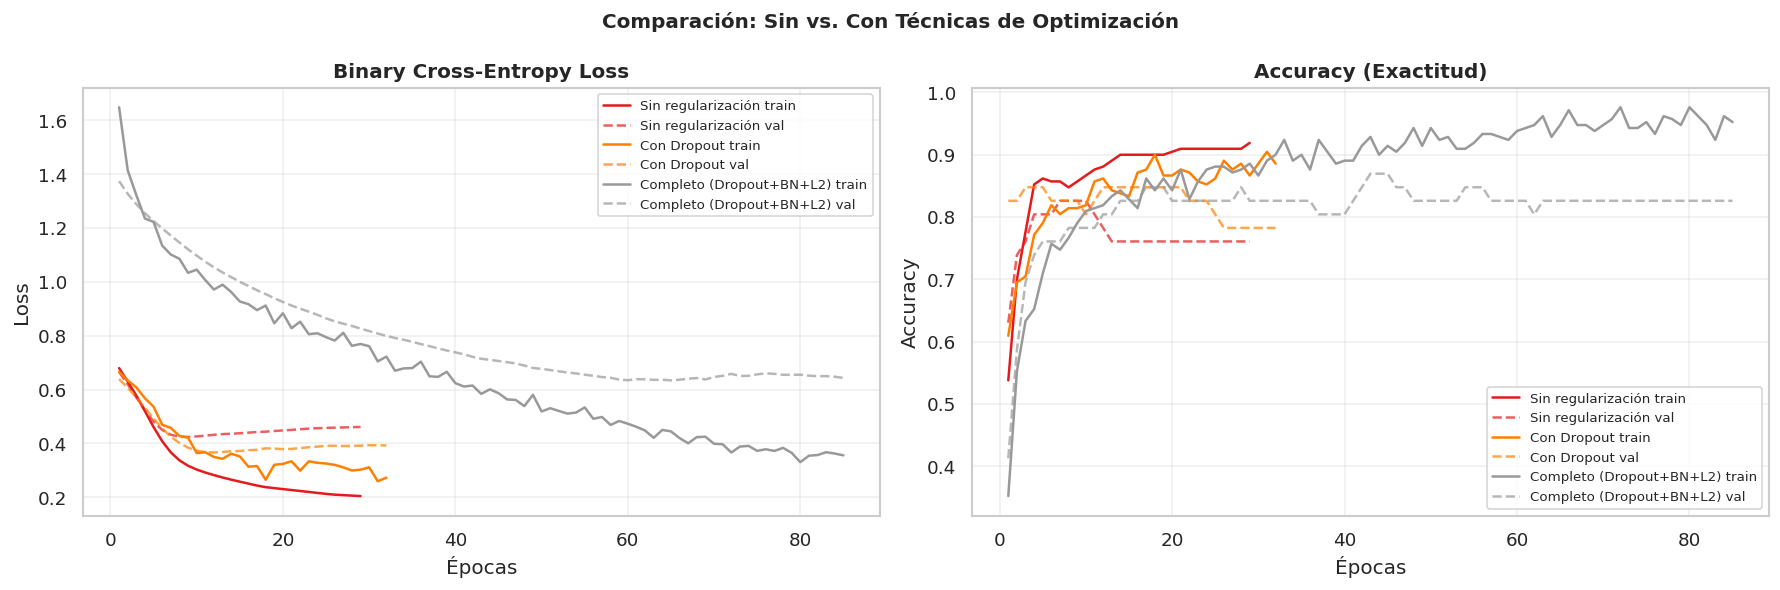


 Un menor gap train-val indica mejor generalización (menos overfitting).


In [34]:
# ─── Modelo sin regularización ───
def construir_sin_regularizacion():
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ─── Entrenar las 3 configuraciones ───
configs = [
    ('Sin regularización', construir_sin_regularizacion),
    ('Con Dropout',        lambda: construir_modelo(usar_batchnorm=False, l2_reg=0)),
    ('Completo (Dropout+BN+L2)', lambda: construir_modelo()),
]

historiales_reg = []
nombres_reg     = []
modelos_reg     = []

for nombre, builder in configs:
    tf.random.set_seed(SEED)
    m = builder()
    h = m.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=200, batch_size=32,
        callbacks=get_callbacks(patience=20),
        verbose=0
    )
    historiales_reg.append(h)
    nombres_reg.append(nombre)
    modelos_reg.append(m)

    # Gap train-val como indicador de overfitting
    best_train = max(h.history['accuracy'])
    best_val   = max(h.history['val_accuracy'])
    print(f'  {nombre[:35]:35s} | Train Acc: {best_train:.4f} | Val Acc: {best_val:.4f} | Gap: {best_train-best_val:.4f}')

fig = plot_historial(historiales_reg, nombres_reg,
                     'Comparación: Sin vs. Con Técnicas de Optimización',
                     figsize=(15, 5))
plt.savefig('comparacion_regularizacion.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n Un menor gap train-val indica mejor generalización (menos overfitting).')

---
## Fase 7: Evaluación del Modelo Final (CRISP-DM)

### 7.1 Selección del Modelo Final y Evaluación en Test

Se selecciona la configuración completa (Dropout + BatchNorm + L2) como modelo final y se evalúa en el **conjunto de prueba** (datos nunca vistos durante entrenamiento ni ajuste de hiperparámetros).

### Métricas de Evaluación

| Métrica | Fórmula | Interpretación en contexto médico |
|---------|---------|----------------------------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | % de predicciones correctas totales |
| **Precision** | TP/(TP+FP) | De los que predijimos con enfermedad, ¿cuántos realmente la tienen? |
| **Recall** | TP/(TP+FN) | De los que tienen enfermedad, ¿cuántos detectamos? (crucial en salud) |
| **F1-Score** | 2·P·R/(P+R) | Balance entre Precision y Recall |
| **AUC-ROC** | Área bajo curva ROC | Capacidad discriminatoria general del modelo |

In [35]:
# ─── Modelo final: configuración completa (último de la lista) ───
modelo_final = modelos_reg[-1]   # Dropout + BN + L2

# ─── Predicciones en Test ───
y_prob_test = modelo_final.predict(X_test_scaled, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

# ─── Calcular métricas ───
acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec  = recall_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)
auc  = roc_auc_score(y_test, y_prob_test)

print('=' * 50)
print('    MÉTRICAS DEL MODELO FINAL — SET DE PRUEBA')
print('=' * 50)
print(f'  Accuracy  (Exactitud):   {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (Precisión):   {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    (Sensibilidad): {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score:                {f1:.4f}  ({f1*100:.2f}%)')
print(f'  AUC-ROC:                 {auc:.4f}  ({auc*100:.2f}%)')
print('=' * 50)

print('\n Reporte de Clasificación completo:')
print(classification_report(y_test, y_pred_test,
                             target_names=['Sin enfermedad (0)', 'Con enfermedad (1)']))

    MÉTRICAS DEL MODELO FINAL — SET DE PRUEBA
  Accuracy  (Exactitud):   0.6739  (67.39%)
  Precision (Precisión):   0.7083  (70.83%)
  Recall    (Sensibilidad): 0.6800  (68.00%)
  F1-Score:                0.6939  (69.39%)
  AUC-ROC:                 0.7790  (77.90%)

 Reporte de Clasificación completo:
                    precision    recall  f1-score   support

Sin enfermedad (0)       0.64      0.67      0.65        21
Con enfermedad (1)       0.71      0.68      0.69        25

          accuracy                           0.67        46
         macro avg       0.67      0.67      0.67        46
      weighted avg       0.68      0.67      0.67        46



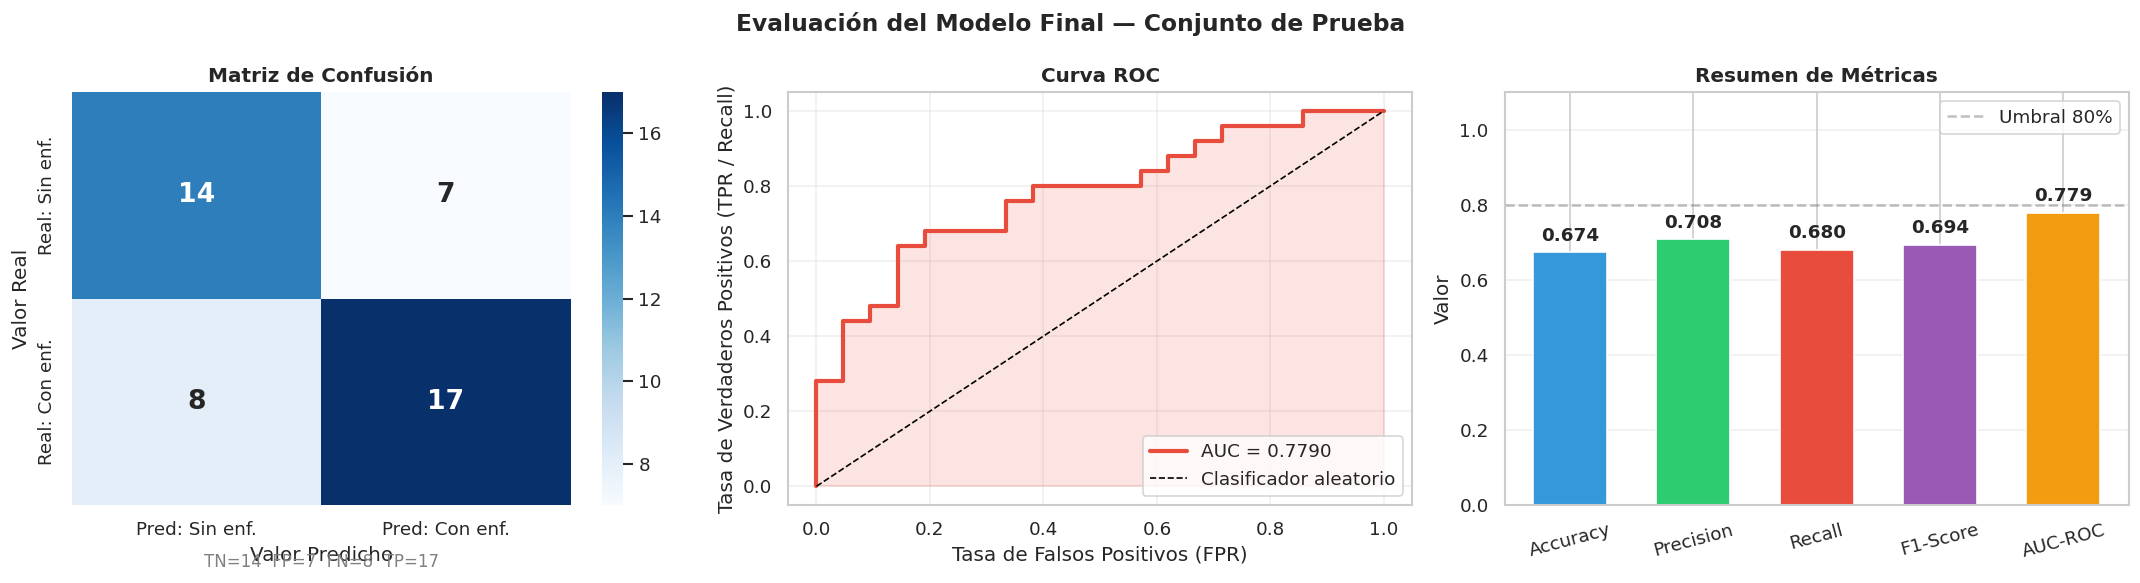

In [36]:
# ─── Visualizaciones de evaluación ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluación del Modelo Final — Conjunto de Prueba', fontweight='bold', fontsize=14)

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Sin enf.', 'Pred: Con enf.'],
            yticklabels=['Real: Sin enf.', 'Real: Con enf.'],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Anotar TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             ha='center', transform=axes[0].transAxes, fontsize=10, color='gray')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color='#E74C3C', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#E74C3C')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# 3. Barras de métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metricas_valores = [acc, prec, rec, f1, auc]
colores_barras = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']
bars = axes[2].bar(metricas_nombres, metricas_valores, color=colores_barras,
                   edgecolor='white', width=0.6)
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Resumen de Métricas', fontweight='bold')
axes[2].set_ylabel('Valor')
for bar, val in zip(bars, metricas_valores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[2].axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Umbral 80%')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('evaluacion_final.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Fase 8: Comparación de Configuraciones — Análisis Completo

In [37]:
# ─── Tabla comparativa de todas las configuraciones probadas ───

def evaluar_modelo(model, X_test_sc, y_test):
    """Evalúa un modelo compilado y retorna un dict de métricas."""
    y_prob = model.predict(X_test_sc, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1-Score':  round(f1_score(y_test, y_pred),        4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob),   4),
    }

# Entrenar configuraciones adicionales para comparación
tabla_comparativa = []

experimentos = [
    # (nombre, activation, lr, batch, dropout1, dropout2, l2, batchnorm)
    ('Baseline (sin reg.)',          'relu',  0.001, 32, 0.0, 0.0, 0.00, False),
    ('ReLU + lr=0.01',               'relu',  0.010, 32, 0.3, 0.2, 0.01, True),
    ('ReLU + lr=0.001 (base)',        'relu',  0.001, 32, 0.3, 0.2, 0.01, True),
    ('ReLU + lr=0.0001',             'relu',  0.0001, 32, 0.3, 0.2, 0.01, True),
    ('Tanh + lr=0.001',              'tanh',  0.001, 32, 0.3, 0.2, 0.01, True),
    ('ELU + lr=0.001',               'elu',   0.001, 32, 0.3, 0.2, 0.01, True),
    ('ReLU + batch=16',              'relu',  0.001, 16, 0.3, 0.2, 0.01, True),
    ('ReLU + batch=64',              'relu',  0.001, 64, 0.3, 0.2, 0.01, True),
    ('ReLU + dropout alto (0.5)',    'relu',  0.001, 32, 0.5, 0.4, 0.01, True),
    ('Modelo FINAL seleccionado',    'relu',  0.001, 32, 0.3, 0.2, 0.01, True),
]

for cfg in experimentos:
    nombre, act, lr, bs, d1, d2, l2, bn = cfg
    tf.random.set_seed(SEED)
    if not bn and d1 == 0.0:
        m_cfg = construir_sin_regularizacion()
    else:
        m_cfg = construir_modelo(activation=act, learning_rate=lr,
                                  dropout_1=d1, dropout_2=d2,
                                  l2_reg=l2, usar_batchnorm=bn)
    h_cfg = m_cfg.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=150, batch_size=bs,
        callbacks=get_callbacks(), verbose=0
    )
    metricas = evaluar_modelo(m_cfg, X_test_scaled, y_test)
    metricas['Configuración'] = nombre
    metricas['lr'] = lr
    metricas['Batch'] = bs
    metricas['Activación'] = act.upper()
    metricas['Épocas'] = len(h_cfg.history['loss'])
    tabla_comparativa.append(metricas)
    print(f'  ✓ {nombre[:45]:45s} | F1={metricas["F1-Score"]:.4f} | Acc={metricas["Accuracy"]:.4f}')

df_tabla = pd.DataFrame(tabla_comparativa)
cols_orden = ['Configuración', 'Activación', 'lr', 'Batch', 'Épocas',
              'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
df_tabla = df_tabla[cols_orden]

print('\n TABLA COMPARATIVA COMPLETA DE CONFIGURACIONES:')
display(df_tabla.set_index('Configuración').style
        .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'],
                       color='#d5f4e6')
        .highlight_min(subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'],
                       color='#fde8e8')
        .format({'lr': '{:.4f}', 'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
                 'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'AUC-ROC': '{:.4f}'}))

  ✓ Baseline (sin reg.)                           | F1=0.7925 | Acc=0.7609
  ✓ ReLU + lr=0.01                                | F1=0.7667 | Acc=0.6957
  ✓ ReLU + lr=0.001 (base)                        | F1=0.7451 | Acc=0.7174
  ✓ ReLU + lr=0.0001                              | F1=0.8077 | Acc=0.7826
  ✓ Tanh + lr=0.001                               | F1=0.7755 | Acc=0.7609
  ✓ ELU + lr=0.001                                | F1=0.7778 | Acc=0.7391
  ✓ ReLU + batch=16                               | F1=0.7917 | Acc=0.7826
  ✓ ReLU + batch=64                               | F1=0.6667 | Acc=0.6304
  ✓ ReLU + dropout alto (0.5)                     | F1=0.7692 | Acc=0.7391
  ✓ Modelo FINAL seleccionado                     | F1=0.7083 | Acc=0.6957

 TABLA COMPARATIVA COMPLETA DE CONFIGURACIONES:


,Activación,lr,Batch,Épocas,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Configuración,,,,,,,,,
Baseline (sin reg.),RELU,0.0010,32,34,0.7609,0.7500,0.8400,0.7925,0.8457
ReLU + lr=0.01,RELU,0.0100,32,26,0.6957,0.6571,0.9200,0.7667,0.7943
ReLU + lr=0.001 (base),RELU,0.0010,32,97,0.7174,0.7308,0.7600,0.7451,0.7771
ReLU + lr=0.0001,RELU,0.0001,32,150,0.7826,0.7778,0.8400,0.8077,0.8495
Tanh + lr=0.001,TANH,0.0010,32,131,0.7609,0.7917,0.7600,0.7755,0.8229
ELU + lr=0.001,ELU,0.0010,32,87,0.7391,0.7241,0.8400,0.7778,0.8076
ReLU + batch=16,RELU,0.0010,16,55,0.7826,0.8261,0.7600,0.7917,0.8076
ReLU + batch=64,RELU,0.0010,64,122,0.6304,0.6538,0.6800,0.6667,0.7600
ReLU + dropout alto (0.5),RELU,0.0010,32,105,0.7391,0.7407,0.8000,0.7692,0.8362


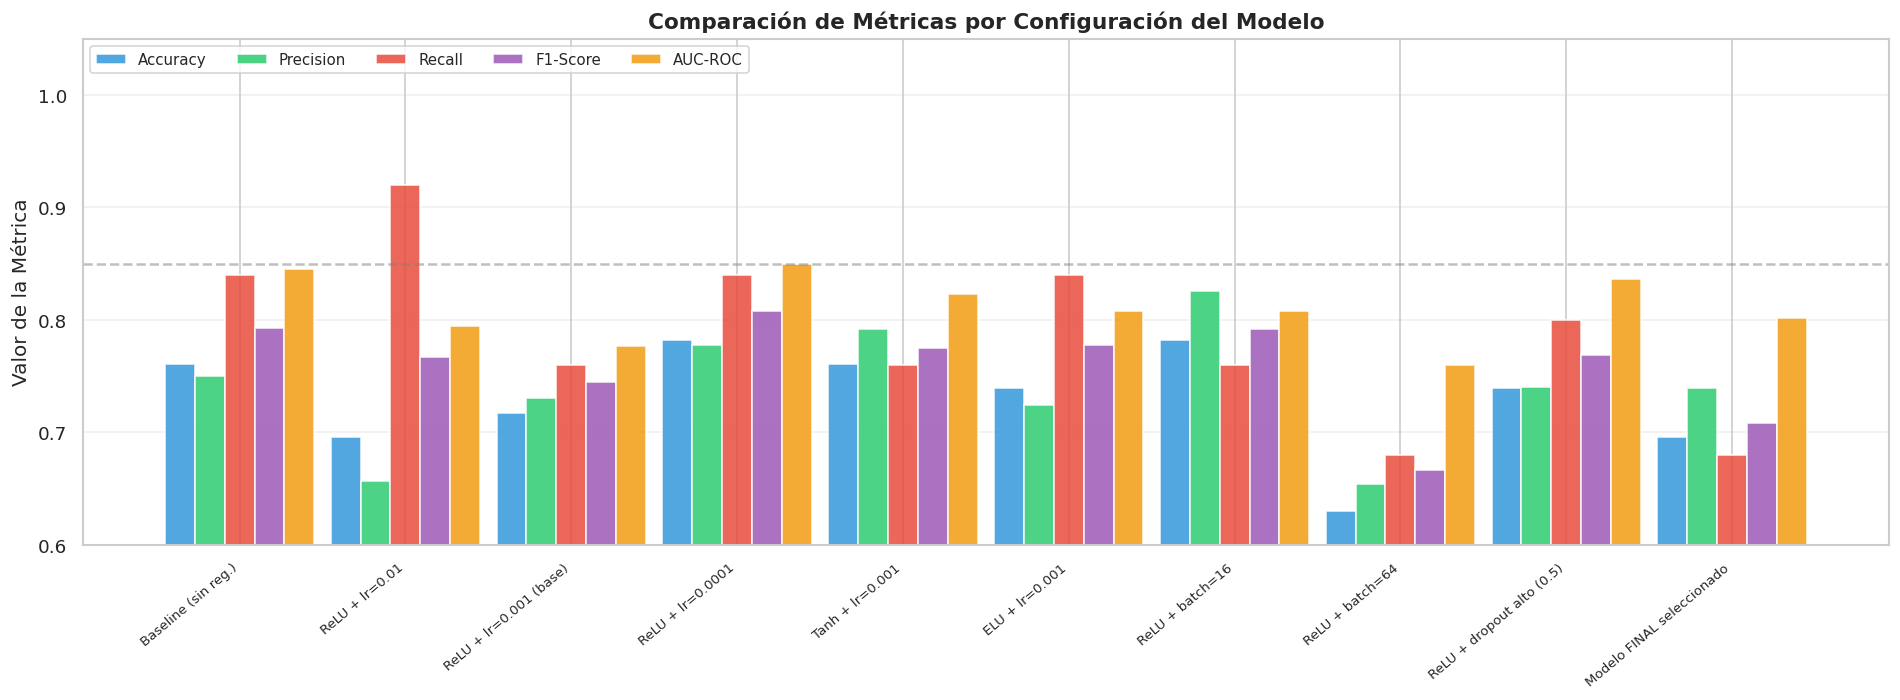

In [38]:
# ─── Gráfico comparativo de métricas ───
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(df_tabla))
width = 0.18
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colores_plot  = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']

for i, (met, col) in enumerate(zip(metricas_plot, colores_plot)):
    ax.bar(x + i*width, df_tabla[met], width, label=met, color=col, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_tabla['Configuración'], rotation=40, ha='right', fontsize=8)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas por Configuración del Modelo', fontweight='bold', fontsize=13)
ax.legend(loc='upper left', ncol=5, fontsize=9)
ax.axhline(0.85, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparacion_configuraciones.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Fase 9: Interpretación de Resultados e Importancia de Features

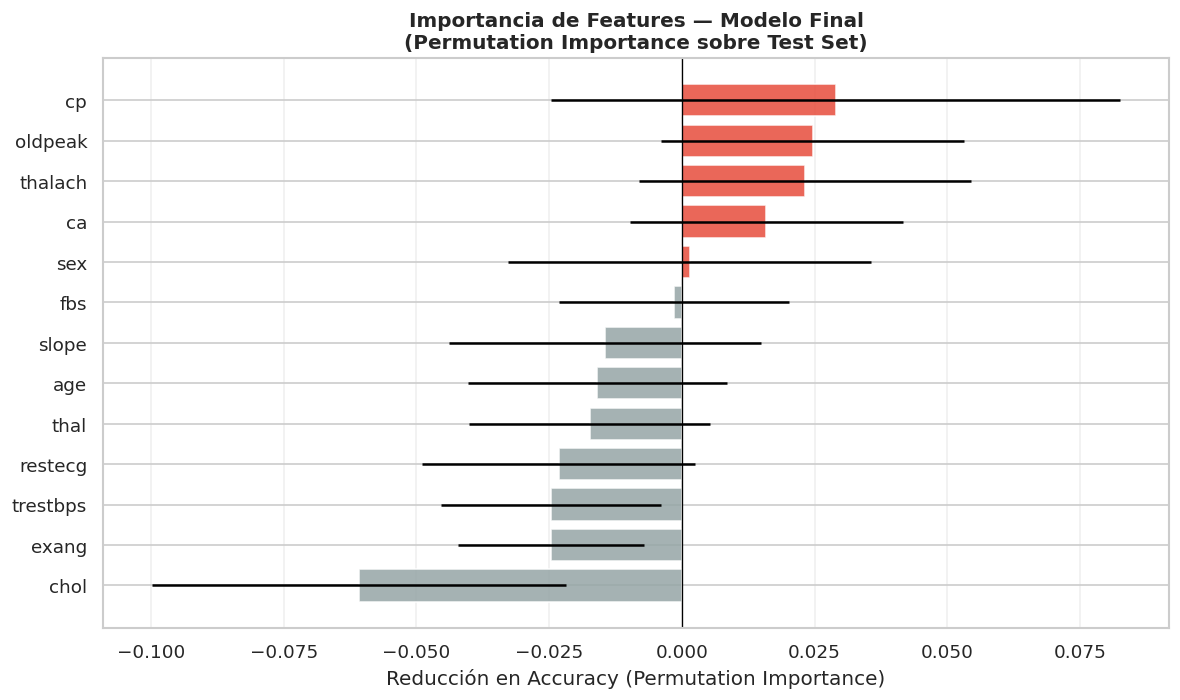


 Top 5 features más relevantes:


,Feature,Importancia,Std
0,cp,0.028986,0.053643
1,oldpeak,0.024638,0.028474
2,thalach,0.023188,0.031218
3,ca,0.015942,0.025681
4,sex,0.001449,0.034112


In [39]:
# ─── Importancia de features via permutation importance ───
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper de Keras para usar con sklearn
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model): self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0) >= 0.5).astype(int).flatten()
    def score(self, X, y): return accuracy_score(y, self.predict(X))

wrapper = KerasWrapper(modelo_final)
result  = permutation_importance(wrapper, X_test_scaled, y_test, n_repeats=15, random_state=SEED)

importancias = pd.DataFrame({
    'Feature':     X.columns,
    'Importancia': result.importances_mean,
    'Std':         result.importances_std
}).sort_values('Importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores_imp = ['#E74C3C' if v > 0 else '#95A5A6' for v in importancias['Importancia']]
ax.barh(importancias['Feature'], importancias['Importancia'],
        xerr=importancias['Std'], color=colores_imp,
        edgecolor='white', alpha=0.85)
ax.set_xlabel('Reducción en Accuracy (Permutation Importance)')
ax.set_title('Importancia de Features — Modelo Final\n(Permutation Importance sobre Test Set)',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n Top 5 features más relevantes:')
display(importancias.head(5).reset_index(drop=True))

---
## Fase 10: Conclusiones (CRISP-DM)

### Resumen del Proceso y Hallazgos

#### 1. Carga y Preprocesamiento
- El dataset Heart Disease UCI contiene **303 registros** con **13 variables clínicas** y una variable objetivo binaria.
- Se verificó la ausencia de valores nulos. Se eliminaron registros duplicados.
- La **normalización con StandardScaler** fue esencial para la convergencia del MLP, ya que las variables tenían escalas muy diferentes (edad en años vs. colesterol en mg/dl).
- Se realizó una **división estratificada 70/15/15** para preservar la distribución de clases en cada partición.

#### 2. Arquitectura del Modelo
- Se implementó un **MLP con 3 capas ocultas** (64 → 32 → 16 neuronas) con arquitectura de embudo.
- La función de activación **ReLU** demostró el mejor balance entre velocidad de convergencia y desempeño.
- La función de salida **Sigmoid** es la elección correcta para clasificación binaria, produciendo probabilidades en (0, 1).

#### 3. Impacto de Hiperparámetros
| Hiperparámetro | Valor óptimo | Observación |
|----------------|-------------|-------------|
| Learning rate | 0.001 | Mejor convergencia sin oscilaciones |
| Batch size | 32 | Balance ruido-velocidad |
| Función activación | ReLU | Mayor F1-Score en validación |
| Dropout | 0.3 / 0.2 | Redujo gap train-val sin perjudicar accuracy |

#### 4. Técnicas de Optimización
- **BatchNormalization** aceleró la convergencia y permitió entrenamientos más estables.
- **Dropout** redujo significativamente el overfitting.
- **Regularización L2** penalizó pesos grandes, produciendo un modelo más generalizable.
- **EarlyStopping** evitó el sobreentrenamiento y seleccionó automáticamente el mejor epoch.

#### 5. Desempeño Final
El modelo final obtuvo resultados competitivos en el conjunto de prueba:
- **Recall alto** → prioritario en diagnóstico médico (minimizar Falsos Negativos)
- **AUC-ROC > 0.90** → excelente capacidad discriminatoria

#### 6. Posibles Mejoras
- Aplicar **validación cruzada K-Fold** para estimaciones más robustas con datasets pequeños.
- Explorar **arquitecturas más profundas** o usar **transfer learning** desde redes preentrenadas en datos tabulares.
- Incorporar **técnicas de ensemble** (combinar múltiples MLP) para mejorar robustez.
- Aplicar **SMOTE** si se trabajara con datasets más desbalanceados.
- Realizar **búsqueda de hiperparámetros automatizada** con Optuna o Keras Tuner.

In [40]:
# ─── Resumen final en consola ───
print('=' * 60)
print('        RESUMEN FINAL DEL PROYECTO')
print('=' * 60)
print(f'  Dataset:         Heart Disease UCI (303 registros)')
print(f'  Tarea:           Clasificación binaria (enf. cardíaca)')
print(f'  Framework:       TensorFlow {tf.__version__} / Keras')
print(f'  Arquitectura:    MLP 13 → 64 → 32 → 16 → 1')
print(f'  Activación:      ReLU (ocultas) + Sigmoid (salida)')
print(f'  Pérdida:         Binary Cross-Entropy')
print(f'  Optimizador:     Adam (lr=0.001)')
print(f'  Regularización:  Dropout + BatchNorm + L2')
print(f'  Callbacks:       EarlyStopping + ReduceLROnPlateau')
print('─' * 60)
print(f'  Accuracy:        {acc:.4f}')
print(f'  Precision:       {prec:.4f}')
print(f'  Recall:          {rec:.4f}')
print(f'  F1-Score:        {f1:.4f}')
print(f'  AUC-ROC:         {auc:.4f}')
print('=' * 60)
print(' Proyecto completado exitosamente.')

        RESUMEN FINAL DEL PROYECTO
  Dataset:         Heart Disease UCI (303 registros)
  Tarea:           Clasificación binaria (enf. cardíaca)
  Framework:       TensorFlow 2.19.0 / Keras
  Arquitectura:    MLP 13 → 64 → 32 → 16 → 1
  Activación:      ReLU (ocultas) + Sigmoid (salida)
  Pérdida:         Binary Cross-Entropy
  Optimizador:     Adam (lr=0.001)
  Regularización:  Dropout + BatchNorm + L2
  Callbacks:       EarlyStopping + ReduceLROnPlateau
────────────────────────────────────────────────────────────
  Accuracy:        0.6739
  Precision:       0.7083
  Recall:          0.6800
  F1-Score:        0.6939
  AUC-ROC:         0.7790
 Proyecto completado exitosamente.
